# **EJERCICIO 4: APLICACIONES BIOLÓGICAS DE MACHINE LEARNING (ML). APRENDIZAJE SUPERVISADO (CLASIFICACIÓN) Y APRENDIZAJE NO SUPERVISADO**

Seguro que habéis oído decir que actualmente vivimos en la "era de los datos". En Biología y Medicina, a menudo tenemos cantidades gigantescas de información (miles de genes, miles de pacientes, millones de células...). Para encontrar patrones y hacer predicciones, usamos algoritmos de **Machine Learning (ML)**.

Vamos a explorar las dos grandes familias de ML, Aprendizaje Supervisado y Aprendizaje No Supervisado) con dos ejemplos muy utilizados en Biología.

## **2.1. APRENDIZAJE SUPERVISADO (DIAGNÓSTICO DE CÁNCER)**

En el **Aprendizaje Supervisado**, entrenamos al algoritmo con datos que  tienen una **respuesta correcta conocida** para que aprenda a predecir futuros casos, en los que no sabemos la respuesta. Un ejemplo típico es aprender a distinguir perros de gatos viendo cientos de fotos ya etiquetadas como "perro" o "gato".

En este ejemplo, usaremos un conjunto de datos real sobre el cáncer de mama (Breast Cancer Dataset).

### **2.1.1. Preparar y entender los datos**

Antes de introducir los datos en el modelo, tenemos que entender cómo se estructuran:
* **Características (*'Features'* o variable 'X'):** Son las "pistas" o medidas de distintas variables que tenemos. En nuestro caso, son los niveles de expresión de distintos genes. Estos datos se encuentran en `breast_cancer_data.csv`.

* **Variable Objetivo (*'Target'* o variable 'y'):** Es la respuesta que queremos predecir. En nuestro ejemplo, es el diagnóstico real de los pacientes: si un individuo tiene cáncer o esta sano. En nuestro caso, encontramos esta información en `breast_cancer_classification.csv`.

Por tanto, nuestro objetivo será entrenar un clasificador que, observando los niveles expresión de un conjunto de genes de un individuo, sea capaz de hacer un diagnóstico, prediciendo la presencia o ausencia de cáncer.

Para cargar los datos en tablas (con el nombre de `dataframes` (o `df`) en Python, utilizamos la función `read_csv`, incorporada en la librería `pandas`. **Atención!!!:** Para cargar los datos correctamente, es muy importante indicar correctamente el separador de las columnas (en este caso, `sep = ','`).

In [ ]:
import pandas as pd

In [ ]:

# Link con los datos de las Features (características).
url_breast_cancer_data = "https://raw.githubusercontent.com/bsc-life/Bojos_supercomputacio/refs/heads/main/2026/data/breast_cancer_data.csv"

# Link los datos del Target (variable objetivo)
url_breast_cancer_class = "https://raw.githubusercontent.com/bsc-life/Bojos_supercomputacio/refs/heads/main/2026/data/breast_cancer_classification.csv"

# Cargamos los datos como dataframes en Python
df_breast_cancer_data = pd.read_csv(url_breast_cancer_data, sep=',', index_col=0)
df_breast_cancer_class = pd.read_csv(url_breast_cancer_class, sep=',', index_col=0)

print("Datos cargados con éxito!")


Datos cargados con éxito!



Mediante la propiedad `.shape` podemos comprobar el número de filas y columnas de los datos que acabamos de importar. Como podéis observar, los datos de secuenciación tienen $214$ filas y $53$ columnas. Las **filas** representan distintos **pacientes**, y las **columnas** distintos **genes**. Los datos de estado, por su parte, tienen $214$ filas (o pacientes, los mismos que antes) y $1$ columna (el estado del paciente).

In [ ]:
df_breast_cancer_data.shape, df_breast_cancer_class.shape

((214, 53), (214, 1))


Para obtener una vista previa de los datos, podemos utilizar la función `.head()`. Esta función nos muestra las primeras filas de los datos. Por defecto, nos muestra las $5$ primeras filas, pero podemos cambiar este número pasándole un número como argumento.

In [ ]:
df_breast_cancer_data.head()

,ACTR3B,ANLN,BAG1,BCL2,BIRC5,BLVRA,BRCA1,BRCA2,CCNB1,CCNE1,...,PHGDH,PTTG1,RRM2,SFRP1,SLC39A6,TMEM45B,TP53,TYMS,UBE2C,UBE2T
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A24L-01,7.15,10.03,10.34,12.01,9.01,10.35,11.57,6.34,10.04,6.79,...,8.28,7.54,10.23,9.32,15.81,7.01,10.10,9.67,9.04,8.77
TCGA-BH-A1EW-11,7.90,7.98,10.05,11.73,6.20,10.45,8.68,8.06,8.65,5.49,...,9.10,6.73,8.35,13.85,14.43,7.13,10.54,7.89,6.66,7.32
TCGA-AC-A3QP-01,7.87,6.33,11.77,10.33,6.07,9.70,9.44,4.81,8.73,4.03,...,8.66,7.44,7.27,11.16,12.59,8.43,10.76,8.18,7.14,6.65
TCGA-E9-A54X-01,7.96,9.92,12.48,11.31,8.60,11.06,9.96,6.06,10.41,5.48,...,9.09,9.10,10.42,3.31,14.44,8.47,9.68,9.10,9.10,8.30
TCGA-BH-A0BS-11,9.05,5.85,10.56,11.14,4.23,9.49,7.40,5.44,7.60,3.91,...,11.59,5.56,6.43,15.19,12.87,6.99,11.07,7.65,5.25,5.36


In [ ]:
df_breast_cancer_class.head()

,sample_type
sample,
TCGA-AR-A24L-01,tumor
TCGA-BH-A1EW-11,healthy
TCGA-AC-A3QP-01,tumor
TCGA-E9-A54X-01,tumor
TCGA-BH-A0BS-11,healthy



Otras funciones interesantes en pandas son:

* `.tail()`: Muestra las últimas filas de los datos.
* `.info()`: Muestra información sobre los datos, como el número de filas y columnas, el tipo de datos, etc.
* `.describe()`: Muestra estadísticas descriptivas de los datos, como la media, la desviación estándar, etc.
* `.isnull()`: Comprueba si hay valores nulos en los datos.
* `.isna()`: Comprueba si faltan datos en alguna fila.
* `.drop_duplicates()`: Elimina las filas duplicadas.

> **Ejercicio 1:** Una vez se han cargado los datos, es momento de comenzar el análsis. Como primeros pasos:

>a) Utiliza las funciones descritas anteriormente para obtener información sobre los datos de secuenciación. Importante: ¿Existen valores nulos o faltan datos en alguna fila? ¿Por qué es importante comprobar esto? ¿Qué harías si realmente faltasen datos?

>b) ¿Qué tipo de datos son los que acabamos de importar? ¿Son datos categóricos o numéricos? ¿Por qué es importante saber esto?

### **2.1.2. Entrenamiento y Evaluación**

##### *Training y Test sets*

En este apartado vamos a enternar un algoritmo para diagnosticar los casos de cáncer de mama. Para ello, utilizaremos los datos de secuenciación que ya hemos importado.

Para entrenar un algoritmo de inteligencia artificial, el primer paso es dividir los datos en dos conjuntos: uno de entrenamiento y otro de test.

* **Training set:** El conjunto de entrenamiento es el que utilizamos para enseñar al algoritmo a distinguir entre los distintos tipos de cáncer. Suele ser el 80% de los datos. El modelo los usa para "estudiar" y encontrar la relación entre los niveles de expresión de los distintos genes y la presencia o ausencia de cáncer.

* **Test set:** El conjunto de test es el que utilizamos para comprobar si el algoritmo ha aprendido correctamente. Sería el 20% restante. Se los ocultamos al modelo durante el entrenamiento y los usamos al final como un **"examen sorpresa"**. Si el modelo saca buena nota en pacientes que nunca ha visto, significa que ha aprendido de verdad y no solo se ha memorizado las respuestas.

In [ ]:

# Vamos a cargar la función que nos permite dividir los datos en entrenamiento y test
from sklearn.model_selection import train_test_split

# Dividimos los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(df_breast_cancer_data, df_breast_cancer_class, test_size=0.2, random_state=2024, stratify=df_breast_cancer_class)
# Comprobamos las dimensiones de los datos
print(f"X_train shape:  {X_train.shape}")
print(f"X_test shape:{X_test.shape}")
print(f"y_train shape:  {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape:  (171, 53)
X_test shape:(43, 53)
y_train shape:  (171, 1)
y_test shape:  (43, 1)



>**Ejercicio 2:** Los datos que acabamos de dividir tienen una estructura de tabla, con filas y columnas. Estas dimensiones son diferentes a las anteriores.
>* ¿Qué significan las dimensiones de los datos que acabamos de imprimir?
>* ¿Qué dimensiones acabamos de separar: pacientes o genes?
>* ¿Por qué crees que los hemos dividido de esta manera y no a la inversa?
>* Comprueba que la suma de las dimensiones de los datos de entrenamiento y test es igual a la dimensión de los datos originales.
>* Comprueba el estado de los pacientes en los conjuntos de entrenamiento y test. ¿Crees que es importante que estén balanceados?

> 🤔 **Pregunta para pensar:** Si le damos el 100% de los datos a la máquina para entrenar y luego la evaluamos con esos mismos datos... ¿qué crees que pasaría? ¿Sería fiable si la llevamos a un hospital real?



#### *Entrenamiento del modelo*

Ahora que tenemos los datos divididos en dos conjuntos, vamos a entrenar un **modelo de clasificación**. En este caso, vamos a utilizar un modelo de clasificación conocido como **Random Forest**. Este modelo es muy potente y se utiliza en multitud de aplicaciones.


In [ ]:
# Importar el modelo de clasificación Random Forest:
from sklearn.ensemble import RandomForestClassifier

In [ ]:

# Vamos a entrenar el modelo para poder distinguir entre pacientes sanos y con tumor.
modelo = RandomForestClassifier(n_estimators=100, random_state=0)

In [ ]:
# Entrenamos el modelo
modelo.fit(X_train, y_train.values.ravel())

RandomForestClassifier(random_state=0)

#### *Predicciones*


Una vez el model está entrenado, hacemos predicciones

Ahora vamos a predecir el estado de los pacientes en el conjunto de test. Los datos de test son los que el modelo no ha visto durante el entrenamiento, es decir, vamos a poder comprobar cómo funciona el modelo con datos que nunca había visto.

Con la función `.predict()`, podemos hacer predicciones con el modelo que acabamos de entrenar.


In [ ]:
# Vamos a hacer predicciones con los datos de test.
predicciones = modelo.predict(X_test)

In [ ]:
print(predicciones)


['healthy' 'healthy' 'tumor' 'healthy' 'healthy' 'healthy' 'healthy'
 'healthy' 'healthy' 'tumor' 'healthy' 'tumor' 'tumor' 'tumor' 'healthy'
 'healthy' 'tumor' 'tumor' 'healthy' 'healthy' 'healthy' 'tumor' 'tumor'
 'tumor' 'tumor' 'healthy' 'healthy' 'tumor' 'healthy' 'tumor' 'tumor'
 'healthy' 'healthy' 'healthy' 'healthy' 'tumor' 'healthy' 'tumor' 'tumor'
 'tumor' 'healthy' 'tumor' 'tumor']


#### *Evaluación del modelo*

Después de que nuestro clasificador prediga el estado de los pacientes del Test set, toca evaluar cómo de correctas son estas predicicciones. Para ello, primero
tenemos que entender los 4 tipos de resultados posibles al diagnosticar a un paciente. Esto se organiza en lo que llamamos una **Matriz de Confusión**:

* **True Positives (TP):** El paciente tiene cáncer y el clasificdor dice: "Cáncer".
* **True Negative (TN):** El paciente está sano y el casificador dice "Sano".
* **False Positive (FP - Falsa Alarma):** El paciente está sano, pero el clasificador dice "Cáncer". (Mal. El paciente se asustará y se hará pruebas innecesaria).
* **False Negative (FN - Peligro):** El paciente tiene cáncer, pero el clasificador dice "Sano". (Esto es muy peligroso, ya que el paciente se irá a casa sin recibir tratamiento).

A partir de estos cuatro casos, calculamos nuestras **Métricas de Evaluación**:

1. **Exactitud (*Accuracy*):** De todos los pacientes, ¿qué porcentaje han sido clasificados correctamente?
   * *Problema:* Si de 100 pacientes, 99 están sanos y 1 tiene cáncer, un clasificador  inútil que siempre diga "Sano" acertará el 99% de las veces (tendrá un 99% de Accuracy), pero habrá fallado en detectar al único enfermo. Por eso necesitamos más métricas.
2. **Precisión (*Precision*):** De entre todos los pacientes clasificados como "Cáncer", ¿cuántos tienen realmente cáncer? Mide la capacidad de no dar Falsas Alarmas (FP).
3. **Sensibilidad o Exhaustividad (*Recall*):** De todos los tumores que *realmente* son malignos, ¿cuántos logró encontrar el clasificador ? Mide la capacidad de no dejar escapar a ningún enfermo (evitar los FN).
4. **F1-Score:** Es una métrica combinada que busca el equilibrio entre la Precisión y el Recall.

In [ ]:

# Vamos a ver cómo de bien ha funcionado el modelo
from sklearn.metrics import classification_report
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

     healthy       0.96      0.96      0.96        23
       tumor       0.95      0.95      0.95        20

    accuracy                           0.95        43
   macro avg       0.95      0.95      0.95        43
weighted avg       0.95      0.95      0.95        43



**Ejercicio 3.** En la tabla anterior hay mucha información. Vamos a intentar entenderla paso a paso:

> a) ¿Cómo calcularías la precisión y la exactitud a partir de los datos reales y las predicciones? Escríbelo en una hoja de papel, que será más fácil.

> b) Intenta implementar una función que calcule la precisión y la exactitud a partir de los datos reales y las predicciones. Puedes utilizar la función classification_report para comprobar si tus cálculos son correctos.

> 🤔 **Pregunta para pensar:** ¿Por qué crees que hace falta tener en cuenta la precisión y la exactitud? ¿Qué pasaría si solo tuviésemos en cuenta una de ellas?


> 🤔 **Pregunta para pensar:** Imagina que programas un clasificaor  para un hospital. ¿Qué preferirías: un modelo con mucha *Precisión* (nunca da falsas alarmas, pero a veces se le escapan enfermos) o un modelo con mucho *Recall* (detecta a casi todos los enfermos, pero a veces asusta a gente sana por error)?

### **2.1.3. Explicabilidad del modelo**

Hemos comprobado que nuestro clasificador funciona muy bien, pero tiene un problema: actúa como una **"Caja Negra"**. Nos da el diagnóstico final, pero no nos explica por qué ha tomado esa decisión. En medicina, no basta con acertar; los médicos necesitan saber qué indicadores biológicos han disparado la alarma.

Aquí es donde entra **SHAP** (SHapley Additive exPlanations).

SHAP calcula **exactamente cuánta culpa o mérito tiene cada variable** (cada gen) en la predicción final. En este ejemplo, vamos a utilizar SHAP para descubrir cuáles son los genes más importantes para clasificar a los pacientes. Si descubirmos que un gen en concreto es el principal responsable de que un tejido se clasifique como "Cáncer", sabemos que será un gen interesante a estudiar como diana de esta enfermedad.


In [ ]:
import shap

In [ ]:
# Inicializamos el explicador de modelos
explainer = shap.Explainer(modelo)

# Calculamos los valores SHAP
shap_values = explainer(X_test)

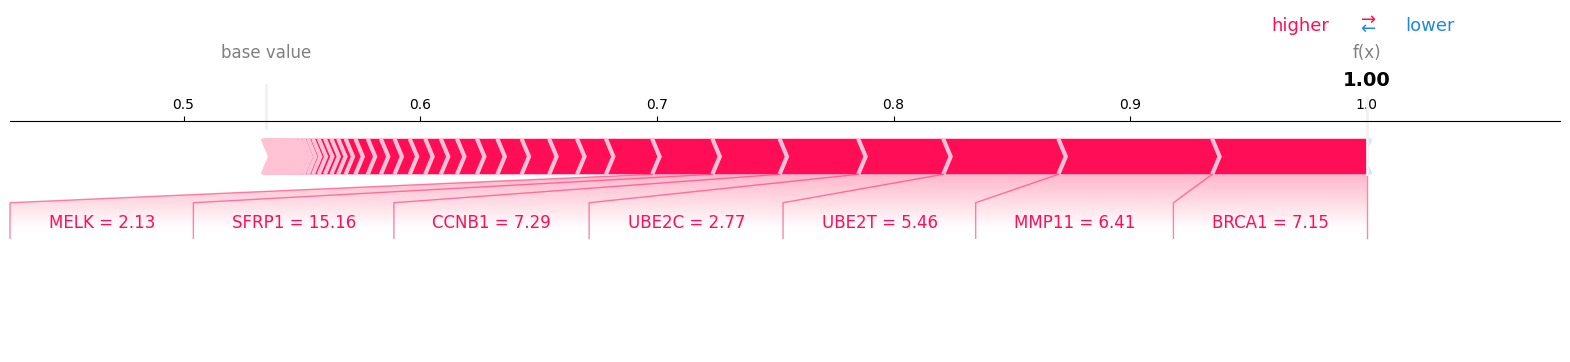

In [ ]:

# Visualizar los valores SHAP
instance_index = 1  # Escoger el paciente a visualizar
class_index = 0     # Escoger la predicción a explicar: 0 -> sano, 1-> tumor

# Creamos un objeto de explicación, Explanation, para poder ver un plot de los resultados
explanation = shap.Explanation(
    values=shap_values[instance_index, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test.iloc[instance_index, :],
    feature_names=X_test.columns,
)

# Creamos el "force plot":
shap.plots.force(explanation, matplotlib=True)


El `force_plot` de la biblioteca SHAP es una herramienta poderosa para interpretar la salida de los modelos de aprendizaje automático. Proporciona una representación visual de las contribuciones de las características a una predicción específica. En el force_plot, cada valor de característica es una fuerza que aumenta o disminuye la predicción. El gráfico está centrado alrededor del valor base (la predicción promedio sobre el conjunto de datos de entrenamiento). Las características que mejoran la predicción se muestran en rojo, aquellas que empeoran la predicción, en azul. El eje x muestra el valor SHAP, que es una medida del impacto de cada característica en la predicción. El eje y enumera las características. El color representa el valor de la característica (rojo alto, azul bajo). El gráfico muestra cómo cada característica contribuye a la predicción del estado de los pacientes.

#### **Conclusiones**

En este ejercicio hemos estudiado cómo se pueden utilizar algoritmos de ML para diagnosticar pacientes con cáncer de mama. Hemos visto cómo se pueden utilizar datos de secuenciación para entrenar un modelo de clasificación y cómo se pueden generar datos sintéticos para aumentar el número de datos de entrenamiento. Además, hemos visto cuáles son los genes que contribuyen más y menos a la clasificación de los pacientes. Este tipo de análisis es fundamental para entender cómo funcionan los modelos de ML y para poder confiar en ellos.


## **2.2. APRENDIZAJE NO SUPERVISADO (EXPLORANDO LO DESCONOCIDO)**

A veces, no tenemos las respuestas correctas. Solo tenemos muchos datos y queremos saber si hay algún orden oculto en ellos. A esto se le llama **Aprendizaje No Supervisado**. Podríamos decir que el algoritmo hace de detective y busca patrones para intentar dar sentido a los datos.

¿Qué ocurriría si tuviéramos los datos de expresión contenidos en `breast_cancer_data.csv` pero no supiéramos el diagnóstico de los pacientes? ¿Podríamos llegar a extraer alguna conclusión sólo con los datos de expresión, o carecerían de utilidad?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Con fines de visualización
sns.set_theme(style="whitegrid", palette="muted")

### **2.2.1. Principal Components Analysis (PCA)**

Hemos visto que `breast_cancer_data.csv`contiene información de $53$ genes

In [ ]:
df_breast_cancer_data.shape

(214, 53)

Los humanos no podemos ver en $53 D$, sólo somos capaces de asimilar representaciones en $2D$ o $3D$.

**PCA** es una técnica que representa los datos en "nuevas" dimensiones (llamadas **"componentes principales"**, seleccionadas para perder la menor cantidad de información posible. Sería análogo a buscar el mejor ángulo para hacerle una foto a un objeto $3D$ de forma que se reconozca perfectamente en una foto $2D$).

<div style="width: 500px; word-wrap: break-word;">
  <img src="https://austinvisuals.com/wp-content/uploads/austin-visuals-2d-vs-3d.jpg" width="500">
  <br>
  <small style="color: gray;">
    <i>Image source: Austin Visuals 3D Animation Studio. Available at: https://austinvisuals.com/</i>
  </small>
</div>


#### *Estandarizar los datos*

Antes de ejecutar PCA, debemos estandarizar los datos. La magnitud de los valores de expresión génica puede variar considerablemente. Si no estandarizamos, los genes con valores numéricos naturalmente más altos dominarán los algoritmos.

* Un **"Gen A"** (encargado del mantenimiento básico de la célula) puede tener niveles de expresión altísimos, variando entre 10.000 y 50.000 unidades.

* Un **"Gen B"** (quizás el responsable de activar un tumor) podría ser muy sutil y variar solo entre 1 y 5 unidades.

Si no estandarizamos, PCA (que busca matemáticamente las mayores variaciones) se centrará solo en el Gen A e ignorará al Gen B, a pesar de que biológicamente sea la clave de nuestra investigación.

**¿Qué hace la estandarización?**
Pone todas las variables en la misma "escala". Transforma los datos para que todos tengan un valor medio de 0. Para lograrlo, coge cada dato ($x$), le resta la media de su grupo ($\mu$), y lo divide por su desviación estándar ($\sigma$):

$$z = \frac{x - \mu}{\sigma}$$

De esta forma, el algoritmo prestará la misma atención a todos los genes, sin importar si sus valores originales eran muy altos residuales.



In [ ]:
# 1. Establecemos la columna 'sample' como índice para evitar que el algoritmo
# la considere como una variable (un gen) más.
if 'sample' in df_breast_cancer_data.columns:
    df_breast_cancer_data.set_index('sample', inplace=True)

# 2. Estandarización de los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_breast_cancer_data)

#### *Ejecutando PCA: Comprimiendo la información genética*

En nuetros datos, tenemos $53$ genes para cada individuo, pero podrían ser datos de expresión de miles. Intentar visualizar y entender un gráfico con miles de dimensiones (una por cada gen) es imposible para el cerebro humano. El algoritmo de PCA toma todos esos  de genes y los combina para crear nuevas variables artificiales llamadas **Componentes Principales (PCs)**. No son genes reales, pero son variables que resumen la información principal.

* **PC1 (Componente Principal 1)** es la nueva variable que captura la mayor cantidad de "información" ( *varianza*, es decir, lo que hace diferentes a unos pacientes de otros).
* **PC2 (Componente Principal 2):** Captura la segunda mayor cantidad de diferencias, siendo independiente del PC1.
* **PC2 (Componente Principal 2):** Captura la segunda mayor cantidad de diferencias, siendo independiente del PC1 y el PC2 ...

...y así sucesivamente.



In [ ]:
# --- Ejecutamos PCA ---

# 1. Calculamos el PCA usando TODOS los componentes posibles.
# Esto nos sirve para ver la curva completa de cuánta información aporta cada uno.
pca = PCA()
pca_result = pca.fit_transform(data_scaled) # data_scaled son nuestros datos ya estandarizados

#### *Curva de varianza explicada - ¿Cuánta información conservamos?*

Al resumir miles de genes en unas pocas variables, inevitablemente perdemos pequeños detalles. Esta curva nos muestra qué porcentaje de la información original logramos retener a medida que añadimos más Componentes Principales.

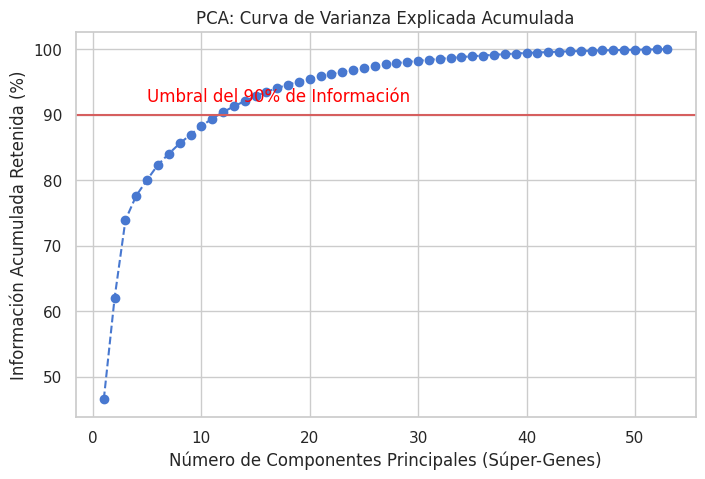

In [ ]:
# 2. Calculamos la Varianza Explicada Acumulada.
# 'explained_variance_ratio_' nos dice qué % de información tiene cada PC.
# np.cumsum va sumando esos porcentajes paso a paso (ej: PC1 + PC2 + PC3...)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

# --- GRÁFICO 1: Curva de Varianza Explicada Acumulada ---
plt.figure(figsize=(8, 5))
# Dibujamos una línea con puntos que va subiendo a medida que sumamos componentes
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('PCA: Curva de Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Información Acumulada Retenida (%)')

# Añadimos una línea roja horizontal en el 90% para ver cuántos PCs necesitamos para llegar a ese nivel
plt.axhline(y=90, color='r', linestyle='-')
plt.text(5, 92, 'Umbral del 90% de Información', color='red')
plt.show()

#### *Scree plot - ¿Cuánta varianza explica exactamente cada PC?*

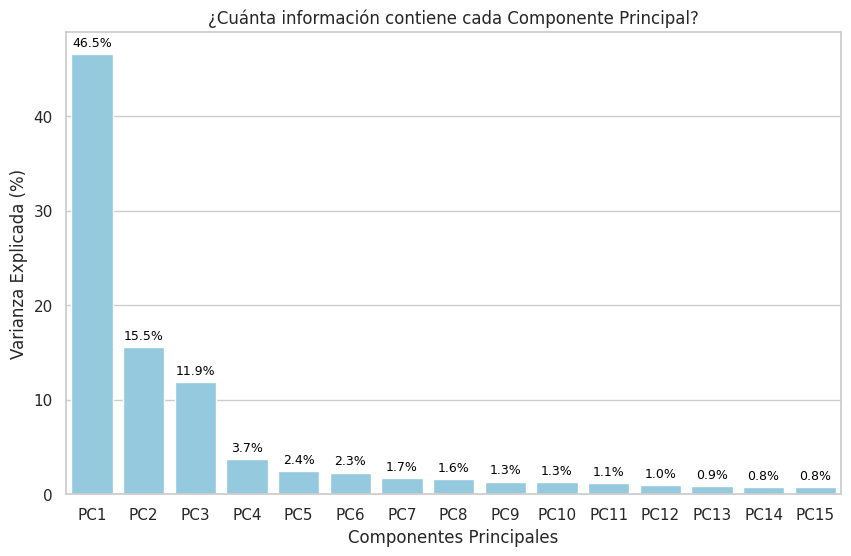

In [ ]:
# --- GRÁFICO 2: Varianza Explicada por Componente (Gráfico de Barras) ---

plt.figure(figsize=(10, 6))

# Como tenemos miles de componentes, dibujar miles de barras sería ilegible.
# Vamos a mostrar solo los primeros 15 (los más importantes).
num_componentes = 15
varianza_individual = pca.explained_variance_ratio_[:num_componentes] * 100
etiquetas_pcs = [f'PC{i}' for i in range(1, num_componentes + 1)]

# Dibujamos el gráfico de barras
sns.barplot(x=etiquetas_pcs, y=varianza_individual, color='skyblue')

plt.title('¿Cuánta información contiene cada Componente Principal?')
plt.xlabel('Principal Components')
plt.ylabel('Varianza Explicada (%)')

# Añadimos el número exacto encima de cada barra para que quede más pro y claro
for i, v in enumerate(varianza_individual):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

A este gráfico de barras se le suele llamar **Scree Plot**, y nos da una información sobre cómo el PCA ha comprimido nuestros datos:

* **PC1:** PC1 es siempre el PC que contiene la mayor cantidad de información genética original

* **El efecto "tobogán":** Después de los primeros PCs, la cantidad de información que aportan los siguientes es cada vez más residual.

Esto es muy positivo porque nos confirma visualmente que la inmensa mayoría de las diferencias entre los tumores de los pacientes están contenidas en esos 3, 4 o 5 primeros PCs. Podemos descartar miles de variables biológicas que apenas aportan información relevante sin miedo a equivocarnos.

> 🤔 **Pregunta para pensar:** Viendo este gráfico de barras y el gráfico de la curva de antes... Si fueras un investigador que necesita crear un test diagnóstico rápido y barato en un hospital que solo pueda analizar 3 Componentes Principales, ¿qué porcentaje de la enfermedad estarías "dejando de ver"? ¿Te parecería un riesgo aceptable?

*Comentar que podemos ver qué genes influyen más en cada PC para tomar decisiones*

#### *Gráfico de dispersión 2D - El mapa de los pacientes*

Vamos a usar solo los dos Componentes Principales más informativos (PC1 y PC2) para plasmar a los pacientes en un plano 2D. Nuestro objetivo es ver si, biológicamente, los pacientes forman agrupaciones naturales.

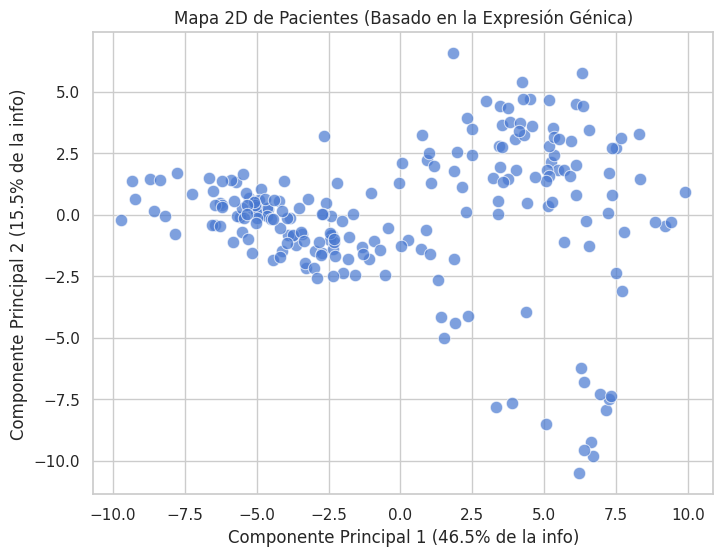

In [ ]:
# --- GRÁFICO 3: Proyección del PCA en 2 Dimensiones (Mapa de Pacientes) ---

# Creamos una tabla (DataFrame) quedándonos SOLO con las dos primeras columnas (PC1 y PC2)
df_pca = pd.DataFrame(data=pca_result[:, :2], columns=['PC1', 'PC2'])
df_pca.index = df_breast_cancer_data.index # Mantenemos los IDs de los pacientes originales

plt.figure(figsize=(8, 6))
# Dibujamos cada paciente como un punto. El eje X es PC1 y el eje Y es PC2.
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.7, s=80)
plt.title('Mapa 2D de Pacientes (Basado en la Expresión Génica)')

# En las etiquetas ponemos exactamente qué porcentaje de información aporta cada eje
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de la info)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de la info)')
plt.show()

En este gráfico, cada punto es un tumor real. Al dibujarlos usando solo PC1 y PC2, vemos cómo se distribuyen en el espacio.
Incluso sin decirle al algoritmo qué tipo de tumor es cada uno, podemos empezar a notar que los puntos no forman un círculo perfecto y aleatorio, sino que se estiran y forman ciertas agrupaciones.

Biológicamente, los pacientes que caen muy cerca unos de otros en este mapa tienen un perfil de expresión génica muy similar.

### **2.2.2. K-means clustering**

Ya tenemos nuestros datos comprimidos en un mapa 2D gracias al PCA. Ahora queremos que el ordenador asigne formalmente cada paciente a un grupo o "cluster". Para esto usaremos el algoritmo **K-Means**.

Para agrupar puntos, el algoritmo necesita utilizar alguna medida de similitud entre pacientes.Existen varias formas matemáticas de medir esto (distancia Manhattan, distancia Coseno...), pero K-Means utiliza por defecto la **Distancia Euclídea**. Esta distancia es exactamente la distancia en línea recta que aprendemos en geometría, calculada con el Teorema de Pitágoras:
$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$. En nuestro mapa del PCA, K-Means calculará esta distancia entre todos los pacientes para agrupar a los que estén más cerca.

#### *Seleccionar el nº de grupos ($k$)*

K-Means necesita saber de antemano cuántos grupos queremos. Como en el aprendizaje no supervisado "estamos a ciegas", usamos dos trucos matemáticos para adivinar el número óptimo:

1. **El Método del Codo (Elbow Method):** Calcula la "Inercia" (cómo de compactos son los grupos). Buscamos un punto en la gráfica donde la curva haga un "codo" o doblez brusco. Ese suele ser el número ideal.

2. **El Método de la Silueta (Silhouette Score):** Mide cómo de separado está un grupo de los demás. La puntuación va de -1 a 1. Cuanto más cerca de 1, mejor y más definidos están los grupos.


Calculando las métricas para encontrar el número óptimo de grupos...


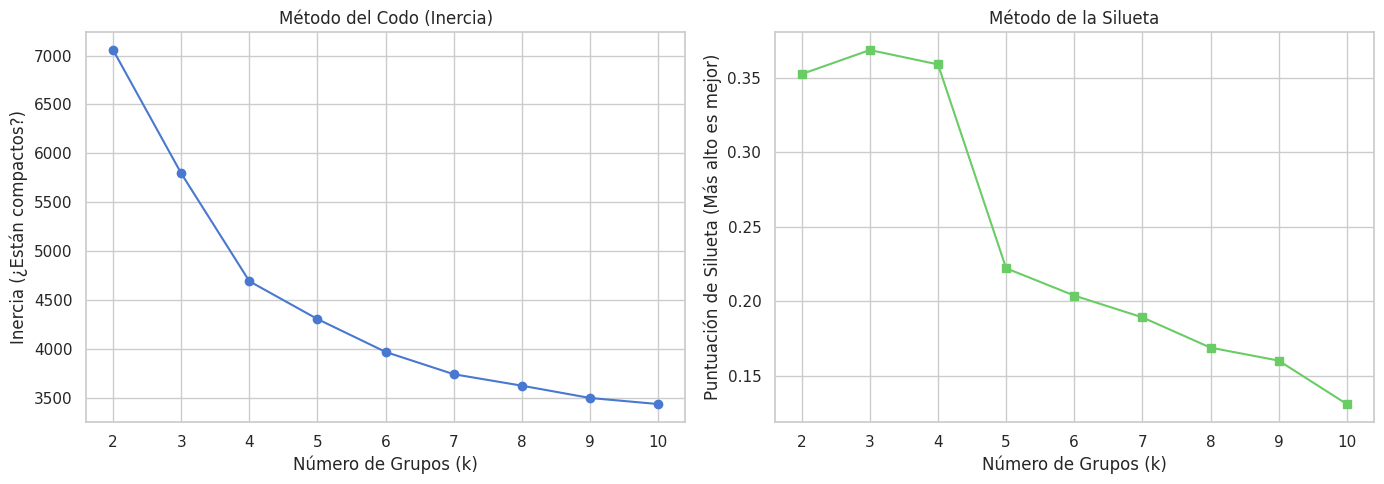

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Calculando las métricas para encontrar el número óptimo de grupos...")

# --- Encontrar el 'k' óptimo ---
inertia = []
silhouette_scores = []
K_range = range(2, 11) # Vamos a probar a hacer desde 2 hasta 10 grupos

for k in K_range:
    # Entrenamos el modelo para cada valor de 'k'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # data_scaled son nuestros datos estandarizados del paso anterior
    cluster_labels = kmeans.fit_predict(data_scaled)

    # Guardamos los resultados
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, cluster_labels))

# --- GRÁFICOS 4 y 5: Codo y Silueta lado a lado ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(K_range, inertia, marker='o', color='b')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Grupos (k)')
ax1.set_ylabel('Inercia (¿Están compactos?)')

# Gráfico de la Silueta
ax2.plot(K_range, silhouette_scores, marker='s', color='g')
ax2.set_title('Método de la Silueta')
ax2.set_xlabel('Número de Grupos (k)')
ax2.set_ylabel('Puntuación de Silueta (Más alto es mejor)')

plt.tight_layout()
plt.show()

Si miramos los gráficos anteriores, es muy probable que los mejores valores matemáticos nos sugieran dividir los datos en 3 o  4 grupos.

Vamos a aprovechar que tenemos cierta información para probar representaciones que nos pueden interesar.

* **$k=2$**: Sabemos que los individuos se pueden diferenciar en "enfermos de cáncer" y "sanos" Nos interesa comprobar si K-means es capaz de agruparlos de acuerdo a este criterio.

* **$k=4$**: El cáncer de mama se divide en 4 subgrupos muy caracterizados. Puede ser interesante comprobar si los grupos se forman manteniendo esta distinción.

#### *$k = 2$*

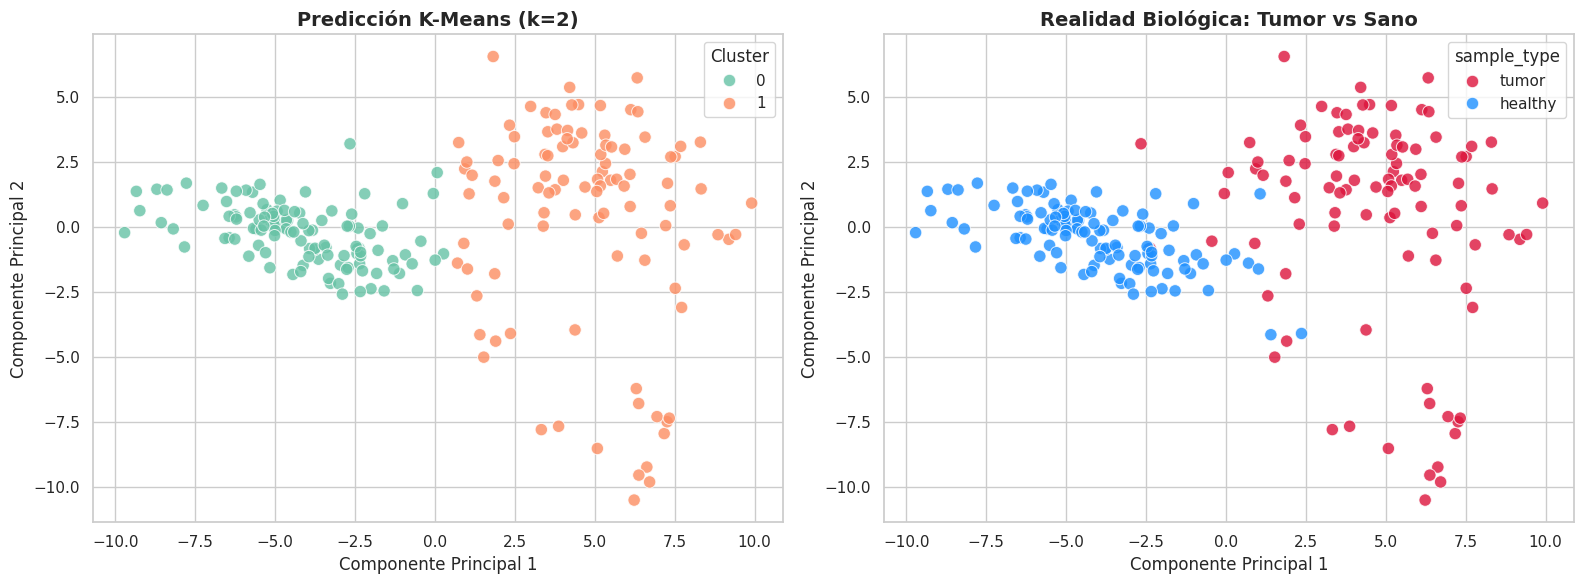

In [ ]:
# --- K-Means Final con k=2 ---
optimal_k = 2
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Asignamos a cada paciente el grupo que la IA ha predicho (0 o 1)
df_pca['Cluster'] = final_kmeans.fit_predict(data_scaled)

# 1. Preparamos los datos reales (Ground Truth) para compararlos
# df_breast_cancer_class es la tabla que tiene la columna 'sample_type' (tumor o normal)
if 'sample' in df_breast_cancer_class.columns:
    df_breast_cancer_class.set_index('sample', inplace=True)

# 2. Unimos la respuesta real a nuestra tabla del PCA
df_pca = df_pca.merge(df_breast_cancer_class[['sample_type']], left_index=True, right_index=True)

# --- GRÁFICA COMPARATIVA ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Lo que predijo el algoritmo a ciegas
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set2', data=df_pca, alpha=0.8, s=80, ax=axes[0])
axes[0].set_title(f'Predicción K-Means (k={optimal_k})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# Gráfica 2: La realidad biológica
custom_colors = {'tumor': 'crimson', 'healthy': 'dodgerblue'} # Tumor rojo, Sano azul
sns.scatterplot(x='PC1', y='PC2', hue='sample_type', palette=custom_colors, data=df_pca, alpha=0.8, s=80, ax=axes[1])
axes[1].set_title('Realidad Biológica: Tumor vs Sano', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

> 🤔 **Pregunta para pensar:** ¡Fíjate en cómo se parecen las dos gráficas! El algoritmo logra separar los tumores del tejido sano analizando solo los niveles de expresión de los genes, sin que nosotros le dijéramos quién estaba enfermo y quién sano.

#### *$k=4$*

El cáncer de mama no es una sola enfermedad. A nivel genético, los médicos y científicos lo dividen principalmente en **4 subtipos moleculares** (conocidos como la clasificación PAM50):
* Luminal A
* Luminal B
* HER2-enriquecido
* Basal-like (Suele coincidir con el triple negativo)

Para comprobar esto, vamos a cargar un nuevo archivo llamado `breast_cancer_Phenotypes.txt` que contiene los datos clínicos detallados de estos pacientes, y vamos a repetir el agrupamiento pidiéndole al algoritmo **$k=4$**.

In [ ]:
# Cargamos los datos clínicos (Fenotipos)
url_breast_cancer_phenotypes = "https://raw.githubusercontent.com/bsc-life/Bojos_supercomputacio/refs/heads/main/2026/data/breast_cancer_Phenotypes.txt"

# Usamos sep='\t' porque es un archivo separado por tabulaciones (texto), no por comas
df_breast_cancer_phen = pd.read_csv(url_breast_cancer_phenotypes, sep='\t')

print("¡Datos clínicos cargados con éxito!")
print("Forma del dataset:", df_breast_cancer_phen.shape)

# Vemos las primeras líneas para entender qué contiene
df_breast_cancer_phen.head()

¡Datos clínicos cargados con éxito!
Forma del dataset: (214, 194)


,sampleID,AJCC_Stage_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,CN_Clusters_nature2012,Converted_Stage_nature2012,Days_to_Date_of_Last_Contact_nature2012,Days_to_date_of_Death_nature2012,ER_Status_nature2012,Gender_nature2012,HER2_Final_Status_nature2012,...,_GENOMIC_ID_TCGA_BRCA_mutation_wustl_gene,_GENOMIC_ID_TCGA_BRCA_miRNA_GA,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_percentile,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_GA_gene,_GENOMIC_ID_TCGA_BRCA_gistic2thd,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_HiSeq_gene,_GENOMIC_ID_TCGA_BRCA_G4502A_07_3,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2,_GENOMIC_ID_TCGA_BRCA_gistic2,_GENOMIC_ID_TCGA_BRCA_PDMarray
0,TCGA-5T-A9QA-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,41ab76d7-fae0-490c-9545-be576b64b827,NaN,TCGA-5T-A9QA-01A-11D-A41E-01,TCGA-5T-A9QA-01,NaN,41ab76d7-fae0-490c-9545-be576b64b827,TCGA-5T-A9QA-01A-11D-A41E-01,NaN
1,TCGA-A2-A04T-01,Stage IIA,62.0,1.0,Stage IIA,2246.0,NaN,Negative,FEMALE,Negative,...,NaN,TCGA-A2-A04T-01,79d7a589-60bd-4b4a-89c1-d557fe24c733,TCGA-A2-A04T-01,TCGA-A2-A04T-01A-21D-A036-01,NaN,TCGA-A2-A04T-01A-21R-A034-07,79d7a589-60bd-4b4a-89c1-d557fe24c733,TCGA-A2-A04T-01A-21D-A036-01,TCGA-A2-A04T-01
2,TCGA-A2-A0CV-01,Stage IIB,41.0,2.0,No_Conversion,1929.0,NaN,Positive,FEMALE,Negative,...,TCGA-A2-A0CV-01A-31D-A10Y-09,NaN,a8154f60-e391-44b5-b378-c944c5e8621d,NaN,TCGA-A2-A0CV-01A-31D-A111-01,TCGA-A2-A0CV-01,TCGA-A2-A0CV-01A-31R-A115-07,a8154f60-e391-44b5-b378-c944c5e8621d,TCGA-A2-A0CV-01A-31D-A111-01,TCGA-A2-A0CV-01
3,TCGA-A2-A0EQ-01,Stage IIA,64.0,4.0,Stage IIA,2426.0,NaN,Negative,FEMALE,Positive,...,TCGA-A2-A0EQ-01A-11W-A050-09,TCGA-A2-A0EQ-01,a083b072-7c1e-4ed6-90cf-1e49d21df4cb,TCGA-A2-A0EQ-01,TCGA-A2-A0EQ-01A-11D-A036-01,NaN,TCGA-A2-A0EQ-01A-11R-A034-07,a083b072-7c1e-4ed6-90cf-1e49d21df4cb,TCGA-A2-A0EQ-01A-11D-A036-01,TCGA-A2-A0EQ-01
4,TCGA-A2-A0ET-01,Stage IIIA,58.0,3.0,No_Conversion,1066.0,NaN,Positive,FEMALE,Negative,...,TCGA-A2-A0ET-01A-31D-A045-09,TCGA-A2-A0ET-01,4eb0c00d-595c-47ee-bcad-818c7723656d,TCGA-A2-A0ET-01,TCGA-A2-A0ET-01A-31D-A036-01,NaN,TCGA-A2-A0ET-01A-31R-A034-07,4eb0c00d-595c-47ee-bcad-818c7723656d,TCGA-A2-A0ET-01A-31D-A036-01,TCGA-A2-A0ET-01


Ejecutando clustering con k=4...
Uniendo la clasificación PAM50...
Generando gráficos comparativos...


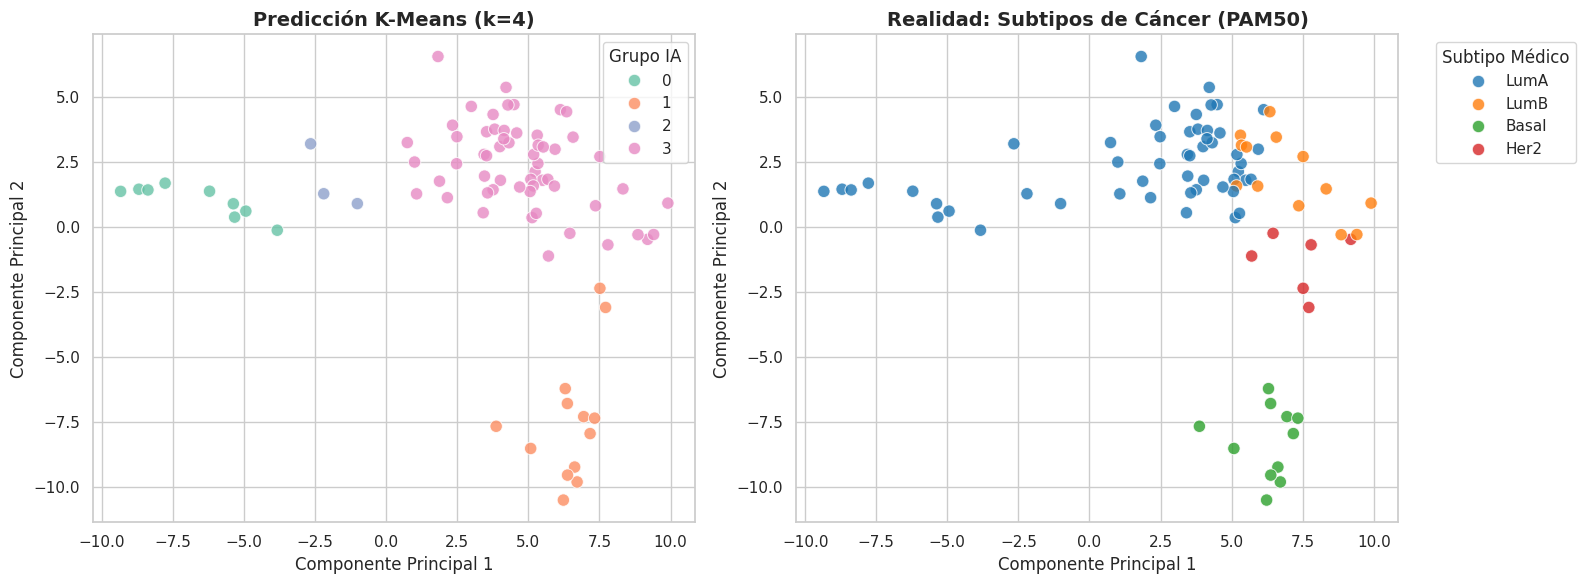

In [ ]:
# ==========================================
# 1. EJECUTAR K-MEANS (k=4)
# ==========================================
print("Ejecutando clustering con k=4...")
optimal_k_4 = 4
final_kmeans_4 = KMeans(n_clusters=optimal_k_4, random_state=42, n_init=10)
df_pca['Cluster_4'] = final_kmeans_4.fit_predict(data_scaled)

# ==========================================
# 2. CRUZAR DATOS CLÍNICOS CON NUESTRO PCA
# ==========================================
print("Uniendo la clasificación PAM50...")

# Extraemos solo el ID del paciente y la columna que dice su subtipo de cáncer ('PAM50Call_RNAseq')
df_clinical_subset = df_breast_cancer_phen[['sampleID', 'PAM50Call_RNAseq']].copy()
df_clinical_subset.set_index('sampleID', inplace=True)

# Lo unimos a nuestra tabla de datos del PCA
df_pca = df_pca.merge(df_clinical_subset, left_index=True, right_index=True, how='left')

# Limpieza: Quitamos pacientes de los que no sabemos el subtipo (NaN)
# y también quitamos el tejido 'Normal' porque ahora solo nos interesan los tumores.
df_pca_clean = df_pca.dropna(subset=['PAM50Call_RNAseq'])
df_pca_clean = df_pca_clean[df_pca_clean['PAM50Call_RNAseq'] != 'Normal']

# ==========================================
# 3. GRAFICAR LOS RESULTADOS
# ==========================================
print("Generando gráficos comparativos...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Lo que agrupó la IA (k=4)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_4', palette='Set2', data=df_pca_clean, alpha=0.8, s=80, ax=axes[0])
axes[0].set_title('Predicción K-Means (k=4)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend(title='Grupo IA')

# Gráfico 2: La Realidad Biológica (Subtipos PAM50)
sns.scatterplot(x='PC1', y='PC2', hue='PAM50Call_RNAseq', palette='tab10', data=df_pca_clean, alpha=0.8, s=80, ax=axes[1])
axes[1].set_title('Realidad: Subtipos de Cáncer (PAM50)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].legend(title='Subtipo Médico', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Al comparar el mapa creado por K-Means (izquierda) con el mapa de los diagnósticos reales (derecha), notaréis algo interesante: **se parecen en cierta medida, pero no son idénticos.**

* **Lo que sí funciona:** El algoritmo agrupa de forma casi perfecta a los tumores del tipo *Basal-like* separándolos del resto. Esto tiene mucho sentido biológico, ya que genéticamente son muy distintos (suelen ser tumores más agresivos y no responden a hormonas).
* **El "desorden":** Los grupos *Luminal A* y *Luminal B* se mezclan mucho más en nuestro mapa de la IA.

> 🤔 **Reflexión final:** ¿Por qué K-Means no logró dibujar los mismos 4 grupos exactos que los médicos? Porque **la biología no es una caja matemática perfecta**. El cáncer es un proceso gradual; las fronteras entre el subtipo Luminal A y Luminal B son muy difusas en la realidad genética. El Machine Learning nos muestra la naturaleza tal y como es: un continuo de datos, no unas simples etiquetas en una libreta de hospital.